# Penguin Linear Regression by Polynomial Regression

In [398]:
# read the variables: class label and features

def string2float(item):
    return float(item) if item != '' else None

def read_strings(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[col] for line in lines[1:]]
    return values

def read_floats(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[col]) for line in lines[1:]]
    return values

In [408]:
filename = 'data/palmer-penguins/palmer-penguins-train.txt'

flipper_lengths = read_floats(filename, col=4)

body_masses = read_floats(filename, col=5)

In [414]:
import numpy as np

x1 = np.array(flipper_lengths)
y = np.array(body_masses)

print(x1.shape)

x0 = np.ones(x1.shape)
print(x0)

(172,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [416]:
# x2 = x1 * x1
x2 = x1 ** 2

print(x1[:10])
print(x2[:10])

[181. 195. 193. 181. 193. 186. 182. 198. 195. 184.]
[32761. 38025. 37249. 32761. 37249. 34596. 33124. 39204. 38025. 33856.]


In [418]:
X = np.stack((x0, x1, x2), axis=1)

print(X.shape)
print(X[:10])

(172, 3)
[[1.0000e+00 1.8100e+02 3.2761e+04]
 [1.0000e+00 1.9500e+02 3.8025e+04]
 [1.0000e+00 1.9300e+02 3.7249e+04]
 [1.0000e+00 1.8100e+02 3.2761e+04]
 [1.0000e+00 1.9300e+02 3.7249e+04]
 [1.0000e+00 1.8600e+02 3.4596e+04]
 [1.0000e+00 1.8200e+02 3.3124e+04]
 [1.0000e+00 1.9800e+02 3.9204e+04]
 [1.0000e+00 1.9500e+02 3.8025e+04]
 [1.0000e+00 1.8400e+02 3.3856e+04]]


In [420]:
result = np.matmul(X.transpose(), X)
result = np.linalg.inv(result)
result = np.matmul(result, X.transpose())
result = np.matmul(result, y)
w = result

print(w)

[ 3.50347651e+04 -3.60558273e+02  1.02243255e+00]


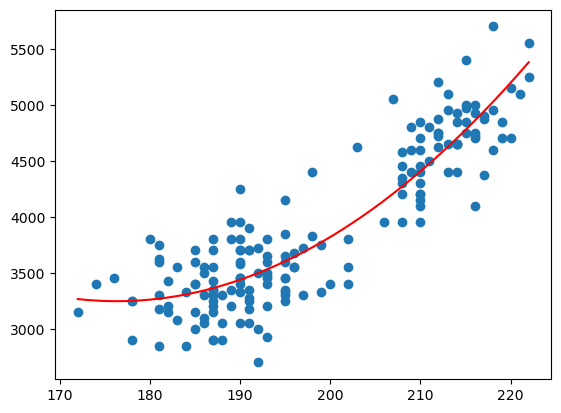

In [422]:
import matplotlib.pyplot as plt

fig = plt.figure()

plt.scatter(x1, y)

xx = np.linspace(x1.min(), x1.max(), 500)
yy = w[0] + w[1] * xx + w[2] * (xx ** 2)

plt.plot(xx, yy, color='red')

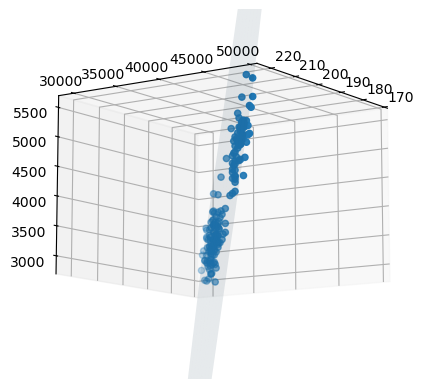

In [426]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X[:,1], X[:,2], y)

rx1 = np.linspace(np.min(x1), np.max(x1), 10)
rx2 = np.linspace(np.min(x2), np.max(x2), 10)
xx1, xx2 = np.meshgrid(rx1, rx2)
yy = w[0] + w[1] * xx1 + w[2] * xx2

ax.plot_surface(xx1, xx2, yy, alpha=0.1)
ax.set_zlim(np.min(y), np.max(y))

ax.view_init(elev=-10, azim=35, roll=0)

In [428]:
# training set evaluation

y_pred = np.matmul(X, w)

diff = y - y_pred
mse = np.mean(diff ** 2)

print(mse)
print(np.mean(y), np.sqrt(mse), np.sqrt(mse)/np.mean(y))

93241.6917818026
3903.343023255814 305.3550258007924 0.07822910361234228


$\mathbf{x} = [x_0, x_1, x_1^2]$ vs. $\mathbf{x} = [x_0, x_1]$

3903.343023255814 335.57111934278447 0.08597018436337207

In [430]:
# test data

filename = 'data/palmer-penguins/palmer-penguins-test.txt'

flipper_lengths =  read_floats(filename, col=4)
body_masses = read_floats(filename, col=5)

x1 = np.array(flipper_lengths)
y = np.array(body_masses)

idx = (x1 != None) & (y != None)
x1 = x1[idx]
y = y[idx]

x0 = np.ones(x1.shape)
X = np.stack((x0, x1, x1 ** 2), axis=1)

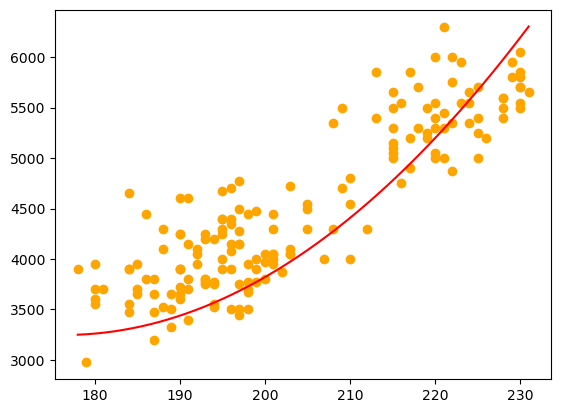

In [432]:
fig = plt.figure()

plt.scatter(x1, y, color='orange')

xx = np.linspace(x1.min(), x1.max(), 500)
yy = w[0] + w[1] * xx + w[2] * (xx ** 2)

plt.plot(xx, yy, color='red')

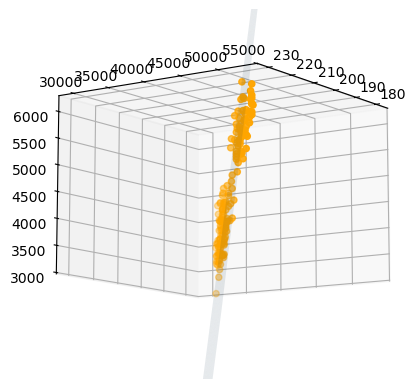

In [436]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X[:,1], X[:,2], y, color='orange')

rx1 = np.linspace(np.min(x1), np.max(x1), 10)
rx2 = np.linspace(np.min(x2), np.max(x2), 10)
xx1, xx2 = np.meshgrid(rx1, rx2)
yy = w[0] + w[1] * xx1 + w[2] * xx2

ax.plot_surface(xx1, xx2, yy, alpha=0.1)
ax.set_zlim(np.min(y), np.max(y))

ax.view_init(elev=-10, azim=35, roll=0)

In [438]:
y_pred = np.matmul(X, w)

diff = y - y_pred
mse = np.mean(diff ** 2)

print(mse)
print(np.mean(y), np.sqrt(mse), np.sqrt(mse)/np.mean(y))

259916.96766298072
4503.676470588235 509.82052495263537 0.11320096554050353


$\mathbf{x} = [x_0, x_1, x_1^2]$ vs. $\mathbf{x} = [x_0, x_1]$

4503.676470588235 506.7945019577786 0.11252906492450268